# Retrieval Evaluation — Baseline Analysis

This notebook analyzes the baseline performance of the semantic retriever.

Baseline configuration:

- Embedding model: `paraphrase-multilingual-MiniLM-L12-v2`
- Knowledge base: `context.txt`
- Retrieval representation: manually defined search keys
- Retrieval threshold: 0.30
- Evaluation dataset: 100 manually curated queries

The analysis separates:
1. ranking performance,
2. retrieval/rejection decisions,
3. performance across query categories and difficulty levels,
4. out-of-domain behavior.

## Imports and loading data

We start by importing the required libraries.

In [1]:
import json
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

We load the results generated by the baseline retrieval experiment.

In [2]:
# Load results
RESULTS_PATH = Path("retrieval_results.json")

with RESULTS_PATH.open("r", encoding="utf-8") as file:
    results = json.load(file)

Check:

In [3]:
print("Type: ", type(results))
print("len: ", len(results))
# Example
results[0]

Type:  <class 'list'>
len:  100


{'case_id': 'fever_001',
 'query': 'Tengo fiebre',
 'expected_id': 'fever',
 'should_retrieve': True,
 'query_type': 'direct',
 'difficulty': 'easy',
 'predicted_id': 'fever',
 'best_score': 0.6667430400848389,
 'retrieved_id': 'fever',
 'expected_rank': 1,
 'retrieval_correct': True,
 'decision_correct': True,
 'ranking': [{'rank': 1, 'id': 'fever', 'score': 0.6667430400848389},
  {'rank': 2, 'id': 'respiratory', 'score': 0.6096863746643066},
  {'rank': 3, 'id': 'headache', 'score': 0.5492120385169983},
  {'rank': 4, 'id': 'abdominal', 'score': 0.4260847568511963},
  {'rank': 5, 'id': 'greeting', 'score': 0.24636825919151306},
  {'rank': 6, 'id': 'hours_location', 'score': 0.18111678957939148},
  {'rank': 7, 'id': 'trauma', 'score': 0.1654168963432312},
  {'rank': 8, 'id': 'appointments', 'score': 0.0965028926730156},
  {'rank': 9, 'id': 'out_of_domain', 'score': 0.011328473687171936},
  {'rank': 10, 'id': 'insurance_payments', 'score': -0.027254842221736908}]}

## Building the dataframe

In [4]:
df = pd.DataFrame(results)
df.head()

,case_id,query,expected_id,should_retrieve,query_type,difficulty,predicted_id,best_score,retrieved_id,expected_rank,retrieval_correct,decision_correct,ranking
0,fever_001,Tengo fiebre,fever,True,direct,easy,fever,0.666743,fever,1.0,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.6667430..."
1,fever_002,Tengo 38.5 de temperatura,fever,True,direct,easy,fever,0.609955,fever,1.0,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.6099554..."
2,fever_003,El termómetro me marca 38.7 desde anoche,fever,True,paraphrase,medium,fever,0.520986,fever,1.0,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.5209861..."
3,fever_004,Estoy con escalofríos y siento el cuerpo muy c...,fever,True,symptom_description,medium,fever,0.711315,fever,1.0,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.7113145..."
4,fever_005,Creo que levanté temperatura y estoy bastante ...,fever,True,paraphrase,medium,fever,0.584605,fever,1.0,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.5846052..."


In [5]:
df.columns

Index(['case_id', 'query', 'expected_id', 'should_retrieve', 'query_type',
       'difficulty', 'predicted_id', 'best_score', 'retrieved_id',
       'expected_rank', 'retrieval_correct', 'decision_correct', 'ranking'],
      dtype='str')

## Sanity checks

We start with some sanity checks, in order to explore the dataframe.

In [6]:
df.shape

(100, 13)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   case_id            100 non-null    str    
 1   query              100 non-null    str    
 2   expected_id        80 non-null     str    
 3   should_retrieve    100 non-null    bool   
 4   query_type         100 non-null    str    
 5   difficulty         100 non-null    str    
 6   predicted_id       100 non-null    str    
 7   best_score         100 non-null    float64
 8   retrieved_id       79 non-null     str    
 9   expected_rank      80 non-null     float64
 10  retrieval_correct  100 non-null    bool   
 11  decision_correct   100 non-null    bool   
 12  ranking            100 non-null    object 
dtypes: bool(3), float64(2), object(1), str(7)
memory usage: 8.2+ KB


In [8]:
df["difficulty"].value_counts()

difficulty
hard      39
medium    36
easy      25
Name: count, dtype: int64

In [9]:
df["query_type"].value_counts()

query_type
paraphrase                20
direct                    18
unknown_out_of_domain     10
unsupported_medical       10
symptom_description        9
colloquial                 9
explicit_out_of_domain     8
noisy                      7
intent_description         4
indirect                   3
greeting_with_noise        2
Name: count, dtype: int64

In [10]:
df["expected_id"].value_counts(dropna=False)

expected_id
NaN                   20
fever                  8
headache               8
respiratory            8
abdominal              8
trauma                 8
appointments           8
hours_location         8
insurance_payments     8
greeting               8
out_of_domain          8
Name: count, dtype: int64

In [11]:
df.groupby(["should_retrieve", "difficulty"]).size()

should_retrieve  difficulty
False            easy           5
                 hard           9
                 medium         6
True             easy          20
                 hard          30
                 medium        30
dtype: int64

We can compute two simple metrics describing the final retrieval behavior.

In [12]:
df["retrieval_correct"].mean()

np.float64(0.63)

In [13]:
df["decision_correct"].mean()

np.float64(0.79)

Remember that `retrieval_correct` tells us whether the system returned the correct ID
(or correctly returned no ID), while `decision_correct` only tells us whether the
system made the correct retrieve-vs-reject decision, regardless of which ID was retrieved.

In [14]:
assert len(df) == 100
assert df["case_id"].is_unique
assert df["ranking"].map(len).eq(10).all()

## Ranking metrics

We first evaluate the ranking produced by the embedding model independently
of the retrieval threshold.

These metrics are computed only for queries with a known relevant document
(`expected_id != None`), since out-of-domain queries with no expected document
do not have a meaningful correct rank.

In [15]:
# Create subset with the expected id not nan
ranking_df = df[df["expected_id"].notna()].copy()
ranking_df["expected_rank"] = ranking_df["expected_rank"].astype(int)

ranking_df.shape

(80, 13)

In [16]:
ranking_df.head()

,case_id,query,expected_id,should_retrieve,query_type,difficulty,predicted_id,best_score,retrieved_id,expected_rank,retrieval_correct,decision_correct,ranking
0,fever_001,Tengo fiebre,fever,True,direct,easy,fever,0.666743,fever,1,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.6667430..."
1,fever_002,Tengo 38.5 de temperatura,fever,True,direct,easy,fever,0.609955,fever,1,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.6099554..."
2,fever_003,El termómetro me marca 38.7 desde anoche,fever,True,paraphrase,medium,fever,0.520986,fever,1,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.5209861..."
3,fever_004,Estoy con escalofríos y siento el cuerpo muy c...,fever,True,symptom_description,medium,fever,0.711315,fever,1,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.7113145..."
4,fever_005,Creo que levanté temperatura y estoy bastante ...,fever,True,paraphrase,medium,fever,0.584605,fever,1,True,True,"[{'rank': 1, 'id': 'fever', 'score': 0.5846052..."


### Top-1 Accuracy

Top-1 Accuracy measures the proportion of queries for which the correct document is ranked first.

In [17]:
ranking_df["top1_correct"] = ranking_df["expected_rank"] == 1

top1_accuracy = ranking_df["top1_correct"].mean()

top1_accuracy

np.float64(0.75)

### Recall@k

Recall@k measures whether the relevant document appears among the first $k$ retrieved results.

Since each query in this benchmark has exactly one relevant document, Recall@k is equivalent to Hit Rate@k.

In this setting, Recall@1 is equivalent to Top-1 Accuracy.

In [ ]:
def recall_at_k(data: pd.DataFrame, k: int) -> float:
    """Compute Recall@k from the rank of the relevant document."""
    return (data["expected_rank"] <= k).mean()

In [19]:
recall_at_1 = recall_at_k(ranking_df, 1)
recall_at_2 = recall_at_k(ranking_df, 2)
recall_at_3 = recall_at_k(ranking_df, 3)
recall_at_5 = recall_at_k(ranking_df, 5)

recall_at_1, recall_at_2, recall_at_3, recall_at_5

(np.float64(0.75), np.float64(0.9), np.float64(0.925), np.float64(1.0))

### Mean Reciprocal Rank — MRR

MRR measures how high the relevant document appears in the ranking.

For each query, the reciprocal rank is:

$$
RR = \frac{1}{\text{rank}}
$$

Therefore, a relevant document ranked first contributes `1.0`, one ranked second contributes `0.5`, one ranked third contributes `0.33`, and so on.

MRR is the mean reciprocal rank across all evaluated queries.

In [20]:
ranking_df["reciprocal_rank"] = 1 / ranking_df["expected_rank"]

mrr = ranking_df["reciprocal_rank"].mean()

mrr

np.float64(0.8514583333333334)

### Summary of ranking metrics

In [21]:
ranking_metrics = pd.Series(
    {
        "Top-1 Accuracy": top1_accuracy,
        "Recall@2": recall_at_k(ranking_df, 2),
        "Recall@3": recall_at_k(ranking_df, 3),
        "Recall@5": recall_at_k(ranking_df, 5),
        "MRR": mrr,
    }
)

ranking_metrics

Top-1 Accuracy    0.750000
Recall@2          0.900000
Recall@3          0.925000
Recall@5          1.000000
MRR               0.851458
dtype: float64

### Performance by difficulty

We now evaluate Top-1 Accuracy across the three difficulty levels defined in
the benchmark.

In [22]:
ranking_by_difficulty = (
    ranking_df.groupby("difficulty")["top1_correct"]
    .agg(["mean", "count"])
    .rename(
        columns={
            "mean": "top1_accuracy",
            "count": "n_cases",
        }
    )
    .reindex(["easy", "medium", "hard"])
)

ranking_by_difficulty

,top1_accuracy,n_cases
difficulty,,
easy,0.850000,20
medium,0.800000,30
hard,0.633333,30


#### Observation

Top-1 Accuracy decreases with query difficulty:

- Easy: 85.0%
- Medium: 80.0%
- Hard: 63.3%

This indicates that the manually defined difficulty levels capture a real
increase in retrieval complexity. The largest degradation occurs for queries
with less lexical overlap, indirect phrasing, colloquial language, or noise.

### Performance by category

We repeat the analysis across the expected retrieval categories.

In [23]:
ranking_by_category = (
    ranking_df.groupby("expected_id")["top1_correct"]
    .agg(["mean", "count"])
    .rename(
        columns={
            "mean": "top1_accuracy",
            "count": "n_cases",
        }
    )
    .sort_values("top1_accuracy")
)

ranking_by_category

,top1_accuracy,n_cases
expected_id,,
out_of_domain,0.500,8
trauma,0.500,8
respiratory,0.625,8
insurance_payments,0.750,8
headache,0.750,8
hours_location,0.750,8
appointments,0.875,8
fever,0.875,8
abdominal,0.875,8


#### Observation

Retrieval performance varies substantially across categories. `greeting`
achieves perfect Top-1 performance in this benchmark, while `trauma` and
`out_of_domain` obtain the lowest Top-1 Accuracy.

This suggests that the errors are not uniformly distributed across the
knowledge base. The next step is to inspect which categories are being
confused and why.

## Error Analysis

Global ranking metrics summarize overall retrieval performance, but they do not show how the model fails.

In this section, we inspect Top-1 errors to identify:

- which categories are most frequently confused,
- whether errors are concentrated in specific query types or difficulty levels,
- and whether incorrect predictions are close competitors or clear ranking failures.

This analysis is performed before modifying the retriever, so that subsequent
changes can be motivated by observed failure modes.

### Identifying Top-1 errors

In [24]:
# Select queries for which the correct document was not ranked first
errors_df = ranking_df[~ranking_df["top1_correct"]].copy()

print(f"Number of Top-1 errors: {len(errors_df)}")
print(f"Top-1 error rate: {len(errors_df) / len(ranking_df):.1%}")

Number of Top-1 errors: 20
Top-1 error rate: 25.0%


In [25]:
error_columns = [
    "case_id",
    "query",
    "expected_id",
    "predicted_id",
    "expected_rank",
    "best_score",
    "difficulty",
    "query_type",
]

errors_df[error_columns]

,case_id,query,expected_id,predicted_id,expected_rank,best_score,difficulty,query_type
6,fever_007,Me desperté temblando y después sentía que me ...,fever,headache,2,0.481317,hard,symptom_description
11,headache_004,Tengo puntadas cerca de la sien,headache,greeting,5,0.375642,medium,symptom_description
15,headache_008,Estoy tratando de trabajar pero tengo puntadas...,headache,appointments,4,0.264085,hard,noisy
17,respiratory_002,Estoy resfriado y congestionado,respiratory,fever,2,0.507782,easy,direct
19,respiratory_004,Tengo la nariz tapada y bastante moco desde ayer,respiratory,headache,2,0.507151,medium,paraphrase
22,respiratory_007,Desde ayer tengo una molestia constante cuando...,respiratory,headache,2,0.288138,hard,paraphrase
24,abdominal_001,Me duele la panza,abdominal,headache,2,0.637501,easy,direct
35,trauma_004,Me di un golpe fuerte y tengo un chichón,trauma,headache,4,0.355838,medium,symptom_description
36,trauma_005,Pisando mal me doblé el tobillo y ahora me duele,trauma,headache,2,0.482873,medium,paraphrase
37,trauma_006,Ayer me fui al piso y hoy tengo toda la zona m...,trauma,greeting,4,0.301383,hard,colloquial


The error table allows us to inspect individual failure cases. In particular,
`expected_rank` distinguishes near misses from more severe ranking failures.

For example, an incorrect prediction with `expected_rank = 2` means that the
relevant document was still a strong candidate, whereas a larger rank indicates
that the correct document was poorly represented in the embedding ranking.

### Which categories are confused?

In [26]:
confusion_counts = pd.crosstab(
    ranking_df["expected_id"],
    ranking_df["predicted_id"],
    rownames=["Expected"],
    colnames=["Predicted"],
)

confusion_counts

Predicted,abdominal,appointments,fever,greeting,headache,hours_location,insurance_payments,out_of_domain,respiratory,trauma
Expected,,,,,,,,,,
abdominal,7,0,0,0,1,0,0,0,0,0
appointments,0,7,0,1,0,0,0,0,0,0
fever,0,0,7,0,1,0,0,0,0,0
greeting,0,0,0,8,0,0,0,0,0,0
headache,0,1,0,1,6,0,0,0,0,0
hours_location,0,0,0,2,0,6,0,0,0,0
insurance_payments,0,2,0,0,0,0,6,0,0,0
out_of_domain,0,0,0,4,0,0,0,4,0,0
respiratory,0,0,1,0,2,0,0,0,5,0


#### Confusion matrix

A confusion matrix provides a more detailed view of Top-1 retrieval errors.

Rows represent the expected document, while columns represent the document
predicted by the retriever. Values on the diagonal correspond to correct
predictions, while off-diagonal values reveal systematic confusions between
categories.

The matrix is normalized by the number of queries in each expected category,
so each row sums to 1.

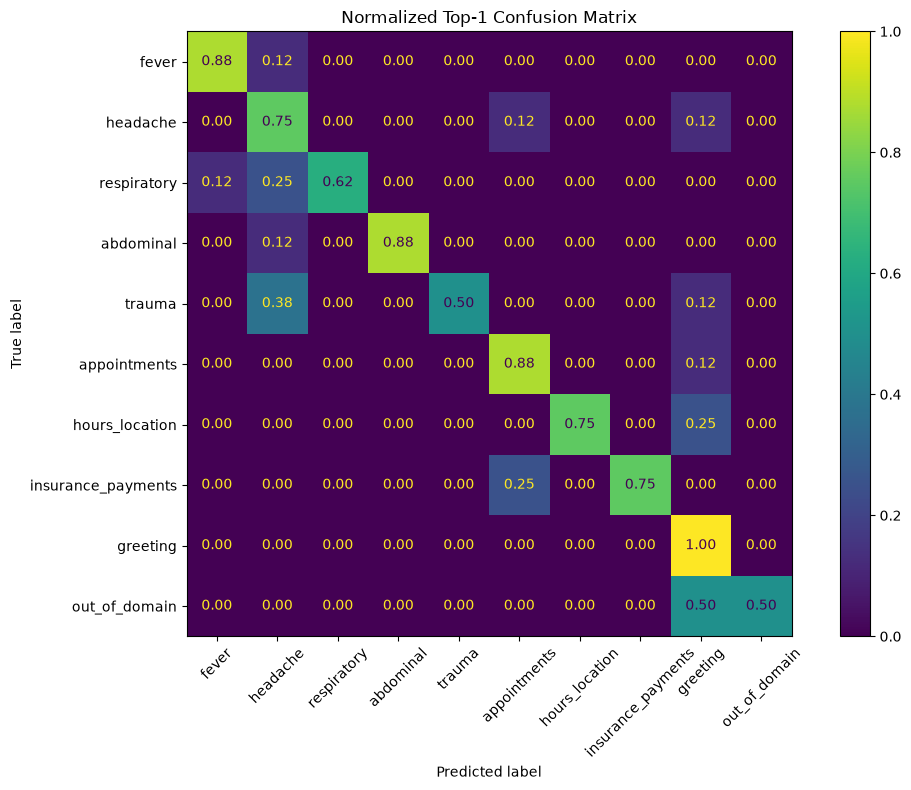

In [28]:
labels = [
    "fever",
    "headache",
    "respiratory",
    "abdominal",
    "trauma",
    "appointments",
    "hours_location",
    "insurance_payments",
    "greeting",
    "out_of_domain",
]

cm = confusion_matrix(
    ranking_df["expected_id"],
    ranking_df["predicted_id"],
    labels=labels,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(11, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

display.plot(
    ax=ax,
    values_format=".2f",
    xticks_rotation=45,
)

ax.set_title("Normalized Top-1 Confusion Matrix")

plt.tight_layout()
plt.show()

### Summary of the most common points of confusion

In [29]:
error_pairs = (
    errors_df.groupby(["expected_id", "predicted_id"])
    .size()
    .reset_index(name="n_errors")
    .sort_values("n_errors", ascending=False)
)

error_pairs

,expected_id,predicted_id,n_errors
7,out_of_domain,greeting,4
11,trauma,headache,3
5,hours_location,greeting,2
6,insurance_payments,appointments,2
9,respiratory,headache,2
2,fever,headache,1
1,appointments,greeting,1
0,abdominal,headache,1
3,headache,appointments,1
4,headache,greeting,1


#### Observation

The errors are not randomly distributed across categories.

The most frequent confusion is `out_of_domain → greeting`, occurring in four
of the eight out-of-domain queries. This suggests that the current embedding
representation does not separate general conversational queries from greetings
particularly well.

Clinical errors also show systematic patterns. `trauma` is frequently confused
with `headache`, while some `respiratory` queries are also ranked as
`headache`.

Administrative categories show a similar overlap: some `insurance_payments`
queries are confused with `appointments`, and some `hours_location` queries
with `greeting`.

These patterns suggest that retrieval errors may depend not only on the
embedding model, but also on how the current search keys represent each
document.

### Score margin

Top-1 Accuracy treats every incorrect ranking equally. However, some errors are
much closer than others.

To characterize this, we define the score margin for incorrect predictions as:

$$
\Delta s =
s_{\mathrm{top1}} - s_{\mathrm{relevant}}
$$

where $s_{\mathrm{top1}}$ is the similarity score of the highest-ranked
document and $s_{\mathrm{relevant}}$ is the score of the expected document.

A small margin indicates a near miss, while a large margin suggests that the
embedding representation strongly favors an incorrect document.

In [ ]:
def get_score_for_id(
    ranking: list[dict],
    target_id: str,
) -> float | None:
    """Return the similarity score associated with a target document ID."""
    for result in ranking:
        if result["id"] == target_id:
            return result["score"]

    return None

In [31]:
errors_df["expected_score"] = errors_df.apply(
    lambda row: get_score_for_id(
        row["ranking"],
        row["expected_id"],
    ),
    axis=1,
)

In [32]:
errors_df["score_margin"] = (
    errors_df["best_score"] - errors_df["expected_score"]
)

In [33]:
errors_with_margin = errors_df[
    [
        "case_id",
        "query",
        "expected_id",
        "predicted_id",
        "expected_rank",
        "best_score",
        "expected_score",
        "score_margin",
        "difficulty",
    ]
].sort_values("score_margin")

errors_with_margin

,case_id,query,expected_id,predicted_id,expected_rank,best_score,expected_score,score_margin,difficulty
19,respiratory_004,Tengo la nariz tapada y bastante moco desde ayer,respiratory,headache,2,0.507151,0.497077,0.010074,medium
38,trauma_007,Me lastimé haciendo ejercicio y desde entonces...,trauma,headache,2,0.467108,0.451824,0.015285,hard
36,trauma_005,Pisando mal me doblé el tobillo y ahora me duele,trauma,headache,2,0.482873,0.460190,0.022683,medium
40,appointments_001,Quiero sacar un turno,appointments,greeting,2,0.387891,0.360347,0.027545,easy
15,headache_008,Estoy tratando de trabajar pero tengo puntadas...,headache,appointments,4,0.264085,0.216881,0.047204,hard
55,hours_location_008,Quería acercarme el sábado y no sé si estará a...,hours_location,greeting,2,0.300120,0.241907,0.058213,hard
22,respiratory_007,Desde ayer tengo una molestia constante cuando...,respiratory,headache,2,0.288138,0.221508,0.066630,hard
54,hours_location_007,"Si salgo tarde del trabajo, ¿todavía llego a q...",hours_location,greeting,2,0.259294,0.173783,0.085511,hard
17,respiratory_002,Estoy resfriado y congestionado,respiratory,fever,2,0.507782,0.420467,0.087315,easy
35,trauma_004,Me di un golpe fuerte y tengo un chichón,trauma,headache,4,0.355838,0.261253,0.094585,medium


#### Observation

The score margins reveal two qualitatively different types of ranking errors.

Some failures are near misses. For example, several `respiratory` and `trauma`
queries have margins below 0.03, meaning that the relevant document was almost
tied with the Top-1 prediction.

Other errors show much larger margins. Several `out_of_domain` queries fall
into this group, indicating that the relevant OOD document is not simply losing
a close competition but is sometimes poorly positioned in the embedding space.

This distinction may become useful when evaluating strategies such as Top-k
retrieval or reranking.

### Where are the errors concentrated?

In [35]:
difficulty_performance = (
    ranking_df.groupby("difficulty")
    .agg(
        n_cases=("case_id", "count"),
        n_errors=("top1_correct", lambda x: (~x).sum()),
        top1_accuracy=("top1_correct", "mean"),
    )
    .reindex(["easy", "medium", "hard"])
)

difficulty_performance["error_rate"] = (
    1 - difficulty_performance["top1_accuracy"]
)

difficulty_performance

,n_cases,n_errors,top1_accuracy,error_rate
difficulty,,,,
easy,20,3,0.850000,0.150000
medium,30,6,0.800000,0.200000
hard,30,11,0.633333,0.366667


#### Observation

The error rate increases consistently with query difficulty:

- Easy: 15.0%
- Medium: 20.0%
- Hard: 36.7%

More than half of all Top-1 errors (11 out of 20) occur among hard queries.
This reinforces the previous observation that indirect phrasing, colloquial
language, noise, and reduced lexical overlap are major challenges for the
current retriever.